In [7]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score, recall_score, precision_score
from sklearn.model_selection import train_test_split

import pandas as pd
from sklearn.impute import SimpleImputer
from plotnine import *
from matplotlib import pyplot as plt
import numpy as np

import seaborn as sns
import tqdm as notebook_tqdm

import io
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [2]:
X_median = pd.read_csv('data/features_imputed_median.csv').iloc[:, 3:]
X_mice = pd.read_csv('data/features_imputed_mice.csv').iloc[:, 3:]
y = pd.read_csv('data/target.csv').iloc[:, 1:]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X_mice, y, test_size=0.3, train_size=0.7, random_state=42)

In [34]:
X_train.index

Index([38015,  2281, 36629,  6087, 11792, 10501,  9279, 35101, 20382, 39166,
       ...
        1685, 16023, 21962, 37194, 16850,  6265, 11284, 38158,   860, 15795],
      dtype='int64', length=28000)

In [38]:
7903 in y_train.index

True

In [36]:
7903 in X_train.index

True

In [30]:
models = {
    'logistic':LogisticRegression(),
    'decision_tree': DecisionTreeClassifier(max_depth=4, max_leaf_nodes=32),
    'random_forest': RandomForestClassifier(),
    'hist_gradient_boosting':HistGradientBoostingClassifier(),
    'gradient_boosting':GradientBoostingClassifier()
}

model_perfomance = {}
trained_models = {}

for model_name in models:
    model = models[model_name]
    model.fit(X_train, y_train)

    y_pred = model.predict_proba(X_test)

    y_proba = model.predict_proba(X_test)
    y_pred = np.argmax(y_pred, axis=1)
    
    model_perfomance[model_name] = {'accuracy': accuracy_score(y_test, y_pred),
                                    'f1_score': f1_score(y_test, y_pred),
                                    'recall':recall_score(y_test, y_pred),
                                    'precision':precision_score(y_test, y_pred)}
    trained_models[model_name] = model
    
#print(model_perfomance)
results = pd.DataFrame(model_perfomance)
display(results)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y

,logistic,decision_tree,random_forest,hist_gradient_boosting,gradient_boosting
accuracy,0.638000,0.617583,0.669167,0.675000,0.675250
f1_score,0.591345,0.656948,0.665712,0.668874,0.666610
recall,0.523572,0.731967,0.658504,0.656172,0.649009
precision,0.679274,0.595877,0.673080,0.682078,0.685192


## Lets Optimize this Model

In [18]:
trained_models

{'logistic': LogisticRegression(),
 'decision_tree': DecisionTreeClassifier(max_depth=4, max_leaf_nodes=32),
 'random_forest': HistGradientBoostingClassifier(),
 'gradient_boosting': GradientBoostingClassifier()}

In [19]:
model = trained_models['random_forest']


y_proba = model.predict_proba(X_test)
y_pred = np.argmax(y_proba, axis=1)

accuracy_score(y_test, y_pred)

0.6730833333333334

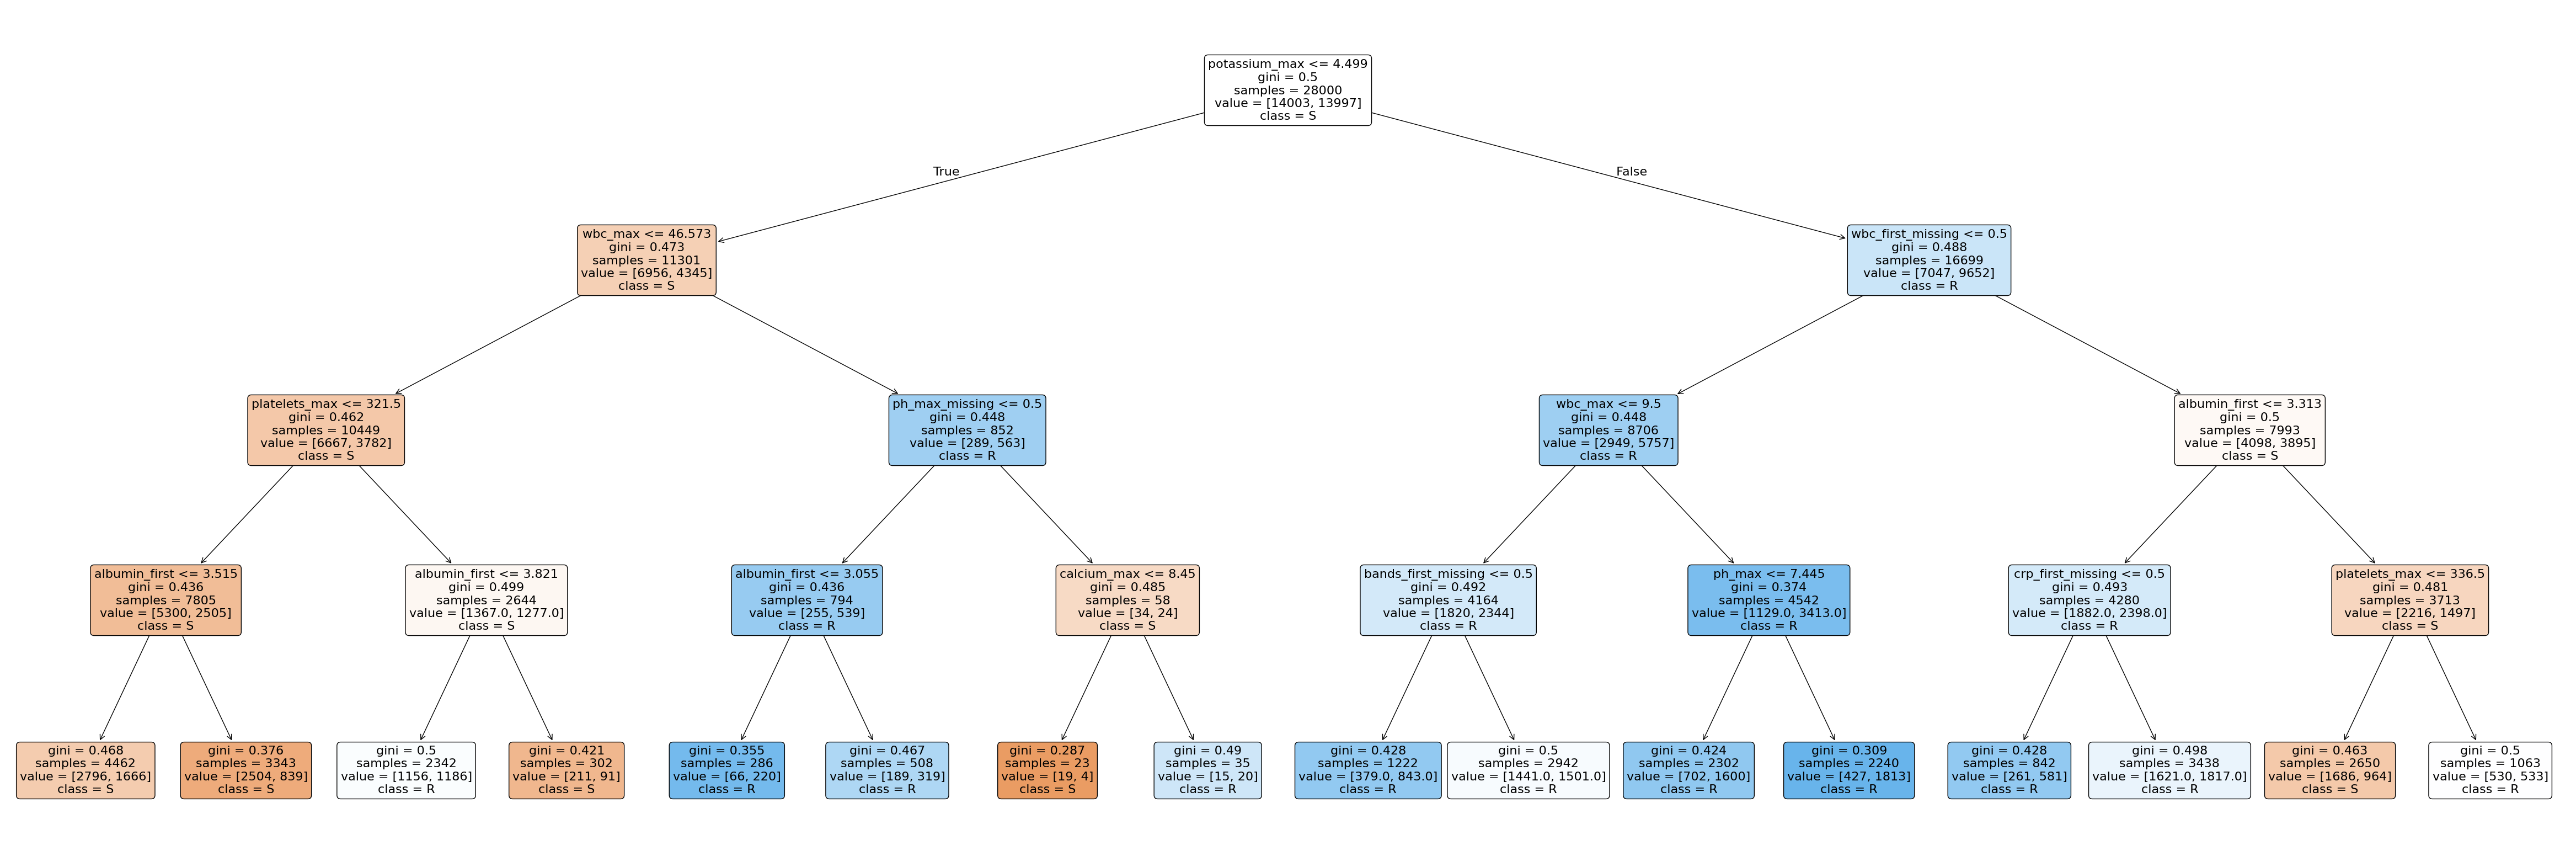

In [20]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(60, 20))
plot_tree(
    trained_models['decision_tree'],                            # your fitted DecisionTreeClassifier
    feature_names=X_mice.columns.tolist(),
    class_names=['S', 'R'],
    filled=True,                    # colour nodes by class
    rounded=True,
    fontsize=16,
    ax=ax
)
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.69      0.68      5997
           1       0.68      0.65      0.67      6003

    accuracy                           0.67     12000
   macro avg       0.67      0.67      0.67     12000
weighted avg       0.67      0.67      0.67     12000



In [22]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
print(dummy.score(X_test, y_test))

0.49975


In [23]:
from sklearn.inspection import permutation_importance

In [24]:
result = permutation_importance(trained_models['gradient_boosting'], X_test, y_test, n_repeats=10, random_state=42)

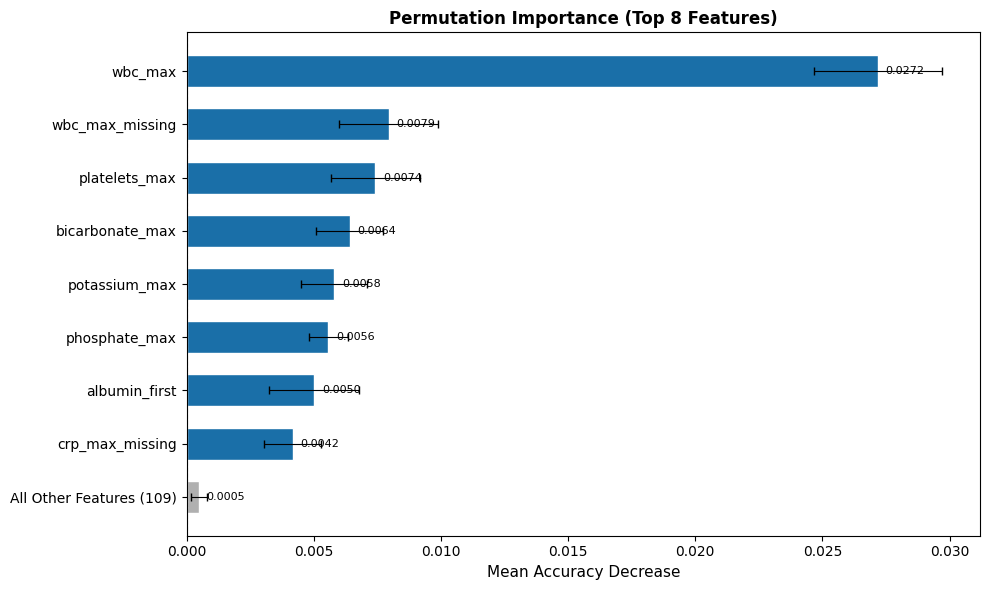

In [ ]:
perm_imp = pd.DataFrame({
    'feature': X_mice.columns,
    'importance': result.importances_mean,
    'std': result.importances_std
}).sort_values('importance', ascending=False)

# Split top 8 vs the rest
top8 = perm_imp.head(8)
others = perm_imp.iloc[8:]

# Aggregate the rest into one row
others_row = pd.DataFrame([{
    'feature': f'All Other Features ({len(others)})',
    'importance': others['importance'].mean(),
    'std': others['std'].mean()
}])

# Combine and sort for plotting (smallest at top → largest at bottom for barh)
plot_df = pd.concat([others_row, top8]).reset_index(drop=True)
plot_df = plot_df.sort_values('importance', ascending=True)

# Color: highlight top 8 vs the aggregated group
colors = ['#b0b0b0'] + ['#1a6fa8'] * 8  # grey for "others", blue for top 8

plt.figure(figsize=(10, 6))
bars = plt.barh(
    plot_df['feature'], 
    plot_df['importance'],
    xerr=plot_df['std'],
    align='center',
    color=colors,
    edgecolor='white',
    height=0.6,
    error_kw=dict(ecolor='black', capsize=3, linewidth=0.8)
)

# Annotate importance values at end of each bar
for bar, val in zip(bars, plot_df['importance']):
    plt.text(val + 0.0003, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', va='center', ha='left', fontsize=8)

plt.title('Permutation Importance (Top 8 Features)', fontsize=12, fontweight='bold')
plt.xlabel('Mean Accuracy Decrease', fontsize=11)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [27]:
perm_imp = pd.DataFrame({
    'feature': X_mice.columns,
    'importance': result.importances_mean
}).sort_values('importance', ascending=False)

# Keep only features with positive importance
important_features = perm_imp[perm_imp['importance'] > 0]['feature'].tolist()

X_train_reduced = X_train[important_features]
X_test_reduced  = X_test[important_features]

print(f"Kept {len(important_features)} of {X_train.shape[1]} features")

Kept 68 of 117 features


In [28]:
X_train_reduced

,wbc_max,wbc_max_missing,platelets_max,bicarbonate_max,potassium_max,phosphate_max,albumin_first,crp_max_missing,ph_max,wbc_first_missing,...,ptt_first_missing,glucose_first_missing,platelets_first,potassium_first,glucose_first,lymphocytes_first,hematocrit_max,magnesium_max_missing,lactate_max,bicarbonate_first
38015,109.952862,1.0,83.0,31.0,6.0,6.6,3.200000,1.0,7.320000,1.0,...,0.0,0.0,77.0,5.2,96.0,8.000000,23.3,0.0,1.400000,21.0
2281,14.140617,1.0,116.0,25.0,4.4,4.4,4.040016,1.0,6.237080,1.0,...,1.0,0.0,116.0,4.4,288.0,14.000000,43.6,0.0,2.640354,22.0
36629,6.000000,0.0,649.0,27.0,4.6,7.9,2.700000,1.0,7.540000,0.0,...,0.0,0.0,265.0,3.7,122.0,13.500000,33.4,0.0,2.000000,23.0
6087,18.698300,1.0,162.0,28.0,4.6,7.0,3.200000,1.0,7.400000,1.0,...,0.0,0.0,162.0,4.6,120.0,26.395968,38.2,0.0,5.600000,16.0
11792,0.000000,0.0,353.0,22.0,4.1,4.2,3.800000,1.0,6.000000,0.0,...,0.0,0.0,353.0,4.1,97.0,39.100000,43.3,0.0,3.600000,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6265,19.144485,1.0,184.0,23.0,4.3,3.2,3.712823,1.0,6.388731,1.0,...,0.0,0.0,184.0,4.0,146.0,28.428031,40.0,0.0,2.300000,20.0
11284,33.515846,1.0,295.0,31.0,5.1,7.4,3.800000,1.0,6.303474,1.0,...,0.0,0.0,260.0,4.8,180.0,31.415588,31.1,0.0,1.818712,24.0
38158,28.464914,1.0,142.0,20.0,5.2,5.6,3.800000,1.0,7.380000,1.0,...,0.0,0.0,142.0,5.2,81.0,30.772997,26.0,0.0,2.300000,16.0
860,10.151564,1.0,89.0,27.0,4.8,7.3,3.700000,1.0,6.540089,1.0,...,0.0,0.0,89.0,2.8,74.0,32.185923,40.7,0.0,3.084689,26.0


In [29]:
models = {
    'logistic':LogisticRegression(),
    'decision_tree': DecisionTreeClassifier(max_depth=4, max_leaf_nodes=32),
    'random_forest': RandomForestClassifier(),
    'hist_gradient_boosting':HistGradientBoostingClassifier(),
    'gradient_boosting':GradientBoostingClassifier()
}

model_perfomance_reduced = {}
trained_models_reduced = {}

for model_name in models:
    model = models[model_name]
    model.fit(X_train, y_train)

    y_pred = model.predict_proba(X_test)

    y_proba = model.predict_proba(X_test)
    y_pred = np.argmax(y_pred, axis=1)
    
    model_perfomance_reduced[model_name] = {'accuracy': accuracy_score(y_test, y_pred),
                                    'f1_score': f1_score(y_test, y_pred),
                                    'recall':recall_score(y_test, y_pred),
                                    'precision':precision_score(y_test, y_pred)}
    trained_models_reduced[model_name] = model
    
#print(model_perfomance)
results_reduced = pd.DataFrame(model_perfomance_reduced)
display(results_reduced)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y

,logistic,decision_tree,random_forest,hist_gradient_boosting,gradient_boosting
accuracy,0.638000,0.617583,0.663750,0.673750,0.675250
f1_score,0.591345,0.656948,0.659695,0.666553,0.666610
recall,0.523572,0.731967,0.651508,0.651841,0.649009
precision,0.679274,0.595877,0.668090,0.681945,0.685192


In [47]:
model = HistGradientBoostingClassifier(
                               random_state=42,)

model.fit(X_train_reduced, y_train)

y_pred = model.predict_proba(X_test_reduced)
y_pred_lbl = np.argmax(y_pred, axis=1)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().


In [48]:
accuracy_score(y_test, y_pred_lbl)

0.6795

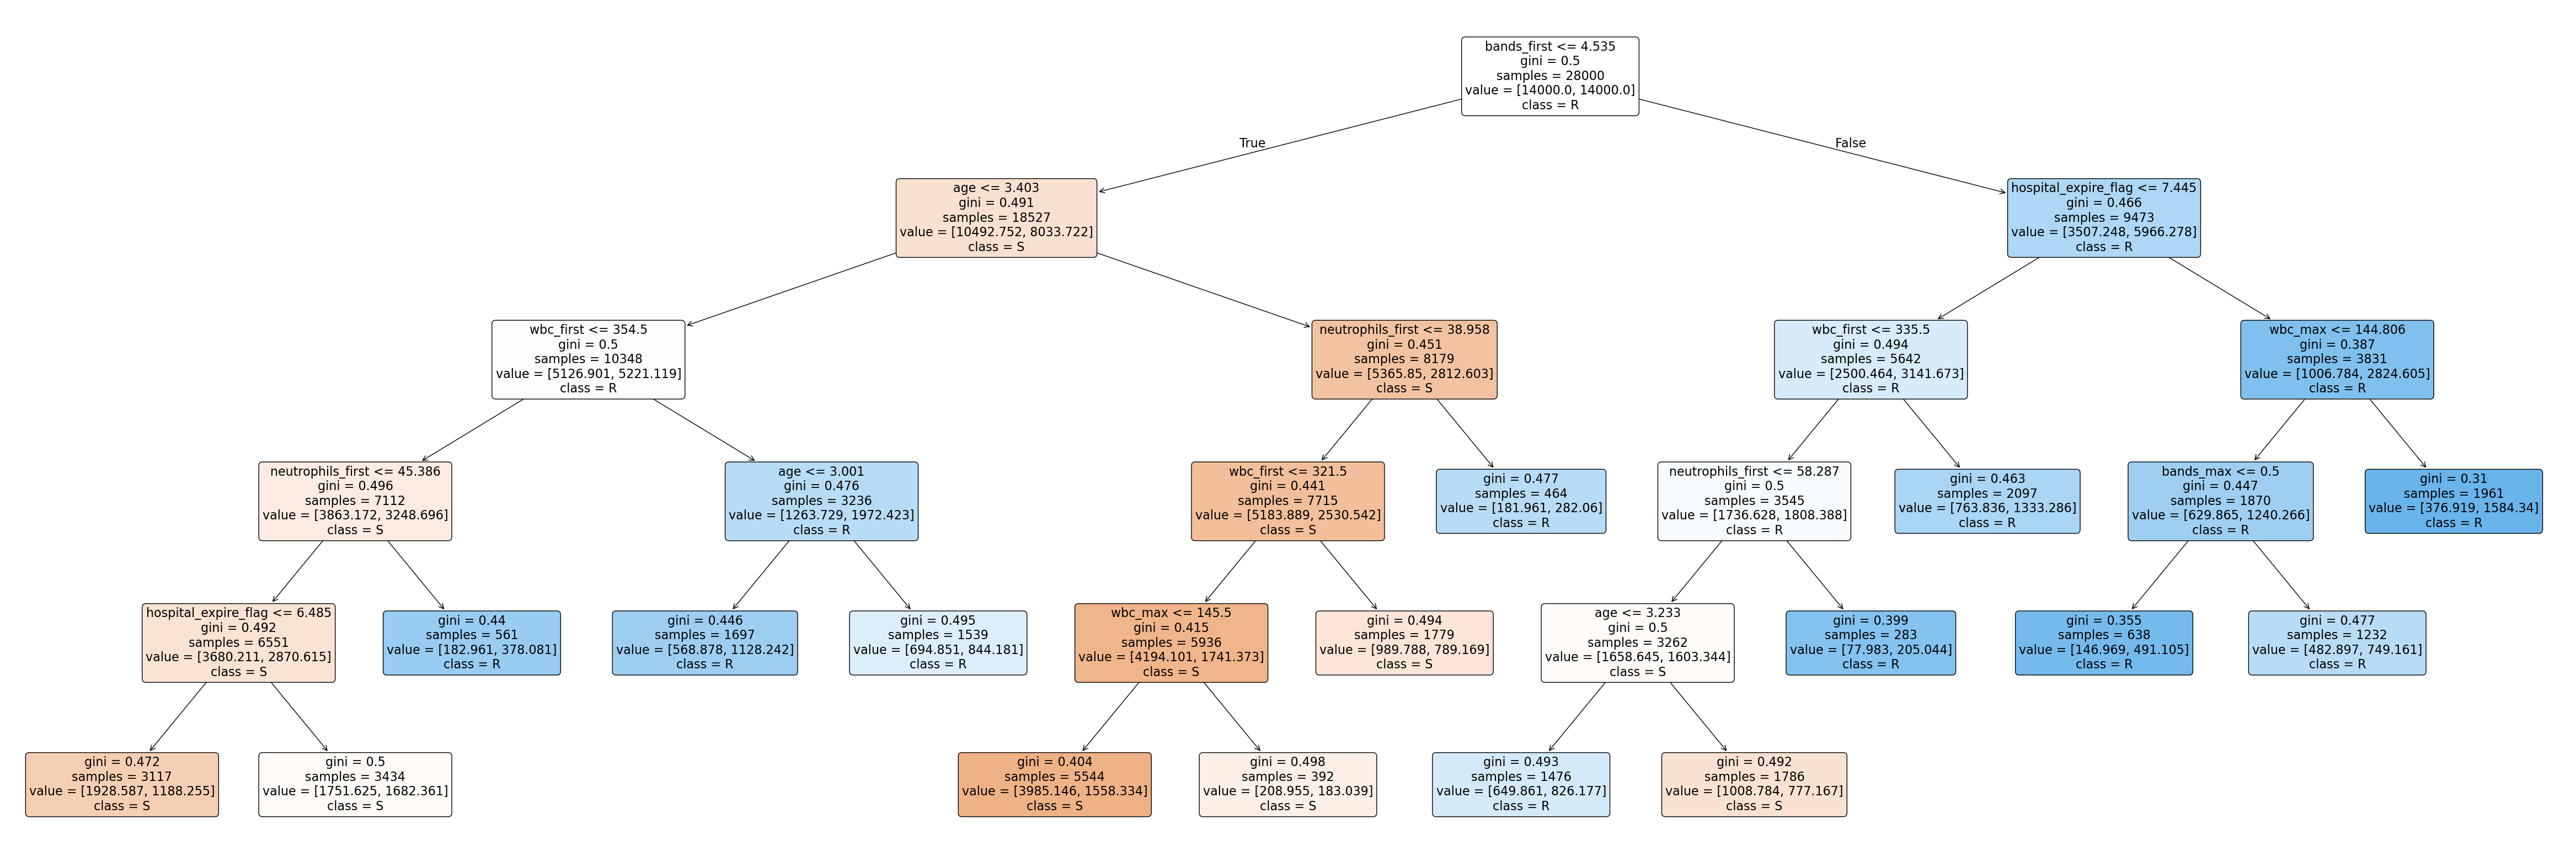

In [88]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(60, 20))
plot_tree(
    model,                            # your fitted DecisionTreeClassifier
    feature_names=X_mice.columns.tolist(),
    class_names=['S', 'R'],
    filled=True,                    # colour nodes by class
    rounded=True,
    fontsize=16,
    ax=ax
)
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

## Using RFECV

In [49]:
from sklearn.feature_selection import RFECV

rfecv = RFECV(
    estimator=model,
    step=1,               # remove 1 feature at a time
    cv=5,                 # 5-fold cross-validation
    scoring='roc_auc',    # optimise for AUC
    min_features_to_select=5
)

rfecv.fit(X_train, y_train)

important_features = X_train.columns[rfecv.support_].tolist()
X_train_reduced = X_train[important_features]
X_test_reduced  = X_test[important_features]

# Visualise the CV scores vs number of features
import matplotlib.pyplot as plt
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1),
         rfecv.cv_results_['mean_test_score'])
plt.xlabel('Number of Features')
plt.ylabel('ROC-AUC')
plt.title('RFECV — Optimal Feature Count')
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().


ValueError: when `importance_getter=='auto'`, the underlying estimator HistGradientBoostingClassifier should have `coef_` or `feature_importances_` attribute. Either pass a fitted estimator to feature selector or call fit before calling transform.

## Explainability

In [19]:
from ciu import CIU

In [50]:
CIU_amr = CIU(model.predict_proba, ['No','Yes'], data = X_train_reduced)
CIU_amr.instance

In [52]:
rng = np.random.default_rng(seed=42)

indices_0 = np.where(y_test == 0)[0]
indices_1 = np.where(y_test == 1)[0]

instance_0 = X_test_reduced.iloc[[rng.choice(indices_0)]]
instance_1 = X_test_reduced.iloc[[rng.choice(indices_1)]]

In [53]:
instance_1

,wbc_max,wbc_first_missing,crp_first_missing,platelets_max,ph_first_missing,ph_max,potassium_max,albumin_first,glucose_max,bicarbonate_max,...,magnesium_first,magnesium_max,potassium_first_missing,lymphocytes_first_missing,hematocrit_max,calcium_max,neutrophils_first_missing,neutrophils_first,hospital_expire_flag,po2_first_missing
23683,21.016873,1.0,0.0,418.0,0.0,5.0,4.8,3.646574,108.0,31.0,...,1.8,2.0,0.0,0.0,35.6,9.6,0.0,74.1,0.0,1.0


In [54]:
7903 in y.index.tolist()

True

In [24]:
y_test.loc[7903]

KeyError: 7903

In [55]:
CIUres_1 = CIU_amr.explain(instance_1, output_inds=1)
display(CIUres_1)

,CI,CU,Cinfl,outname,outval,feature,ymin,ymax,inputs,invals,neutralCU,target_concept,target_inputs
wbc_max,0.162518,0.204800,-0.047975,Yes,0.621438,wbc_max,0.588155,0.750673,[0],[21.016872756653715],0.5,None,None
wbc_first_missing,0.017790,0.000000,-0.008895,Yes,0.621438,wbc_first_missing,0.621438,0.639229,[1],[1.0],0.5,None,None
crp_first_missing,0.145893,1.000000,0.072947,Yes,0.621438,crp_first_missing,0.475545,0.621438,[2],[0.0],0.5,None,None
platelets_max,0.242535,0.792579,0.070961,Yes,0.621438,platelets_max,0.429210,0.671745,[3],[418.0],0.5,None,None
ph_first_missing,0.006077,0.000000,-0.003038,Yes,0.621438,ph_first_missing,0.621438,0.627515,[4],[0.0],0.5,None,None
ph_max,0.052725,0.035386,-0.024497,Yes,0.621438,ph_max,0.619573,0.672298,[5],[5.0],0.5,None,None
potassium_max,0.087388,0.571134,0.006216,Yes,0.621438,potassium_max,0.571528,0.658916,[6],[4.8],0.5,None,None
albumin_first,0.214636,0.379368,-0.025892,Yes,0.621438,albumin_first,0.540013,0.754648,[7],[3.6465742468382634],0.5,None,None
glucose_max,0.085207,0.000000,-0.042603,Yes,0.621438,glucose_max,0.621438,0.706645,[8],[108.0],0.5,None,None
bicarbonate_max,0.158364,1.000000,0.079182,Yes,0.621438,bicarbonate_max,0.463075,0.621438,[9],[31.0],0.5,None,None


In [56]:
plot_df = CIUres_1[~((CIUres_1["CI"].abs() < 1e-9) & (CIUres_1["CU"].abs() < 1e-9))]

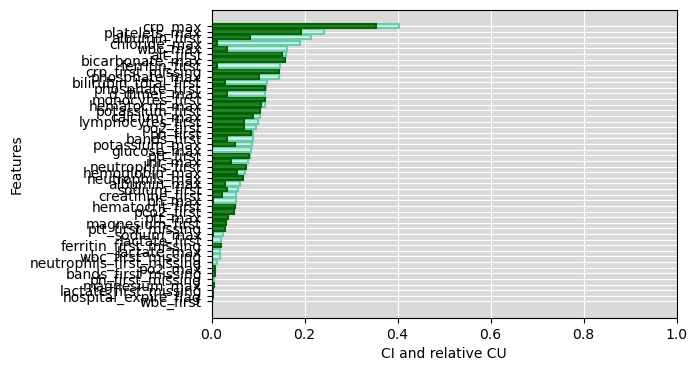

In [57]:

CIU_amr.plot_ciu(plot_df, plot_mode="overlap", figsize=(6,4))

In [28]:
plot_df

,CI,CU,Cinfl,outname,outval,feature,ymin,ymax,inputs,invals,neutralCU,target_concept,target_inputs
los_hours,0.418368,0.868219,0.154051,Yes,0.696189,los_hours,0.332953,0.751322,[0],[203.0],0.5,None,None
wbc_max,0.208742,0.431396,-0.014321,Yes,0.696189,wbc_max,0.606138,0.814880,[1],[21.016872756653715],0.5,None,None
wbc_first_missing,0.027951,0.000000,-0.013976,Yes,0.696189,wbc_first_missing,0.696189,0.724140,[2],[1.0],0.5,None,None
crp_first_missing,0.141670,1.000000,0.070835,Yes,0.696189,crp_first_missing,0.554519,0.696189,[3],[0.0],0.5,None,None
ph_max,0.020229,1.000000,0.010115,Yes,0.696189,ph_max,0.675959,0.696189,[4],[5.0],0.5,None,None
platelets_first,0.057368,1.000000,0.028684,Yes,0.696189,platelets_first,0.638820,0.696189,[5],[418.0],0.5,None,None
ph_first_missing,0.005596,0.000000,-0.002798,Yes,0.696189,ph_first_missing,0.696189,0.701785,[6],[0.0],0.5,None,None
platelets_max,0.021850,1.000000,0.010925,Yes,0.696189,platelets_max,0.674339,0.696189,[7],[418.0],0.5,None,None
ph_first,0.043018,1.000000,0.021509,Yes,0.696189,ph_first,0.653170,0.696189,[8],[5.0],0.5,None,None
age,0.109981,0.470207,-0.003277,Yes,0.696189,age,0.644475,0.754456,[9],[66.0],0.5,None,None


In [29]:
resistant_indices = rng.choice(indices_1, 4)

In [30]:
def get_ciu_results(resistant_indices):
    CIU_amr = CIU(model.predict_proba, ['No','Yes'], data = X_train_reduced)
    CIU_amr.instance

    ciu_results = {}
    for i in resistant_indices:
        instance_1 = X_test_reduced.iloc[[i]]
        CIUres_1 = CIU_amr.explain(instance_1, output_inds=1)
        plot_df = CIUres_1[~((CIUres_1["CI"].abs() < 1e-9) & (CIUres_1["CU"].abs() < 1e-9))] #Removes the really small values, pretty much because I have in some cases 119 features
        ciu_results[i]=plot_df #Cleaner datagframe for plotting

    return ciu_results

In [31]:
def plot_ciu_instances(ciu_results):
    keys = list(ciu_results.keys())
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for i, key in enumerate(keys):
        result = ciu_results[key]
        
        # plot_ciu renders internally — grab the figure it just created
        CIU_amr.plot_ciu(result, plot_mode="overlap", figsize=(6, 4))
        p = plt.gcf()  # <-- capture whatever figure is currently active
        
        # Capture it to a buffer
        buf = io.BytesIO()
        p.savefig(buf, format="png", bbox_inches="tight")
        buf.seek(0)
        plt.close(p)  # close the internal figure
        
        # Paste into the subplot as an image
        img = mpimg.imread(buf)
        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(f"Instance {key}")

    # Hide unused axes
    for j in range(len(keys), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout(h_pad=1.0)
    plt.show()
    return

In [32]:
ciu_results = get_ciu_results(resistant_indices)

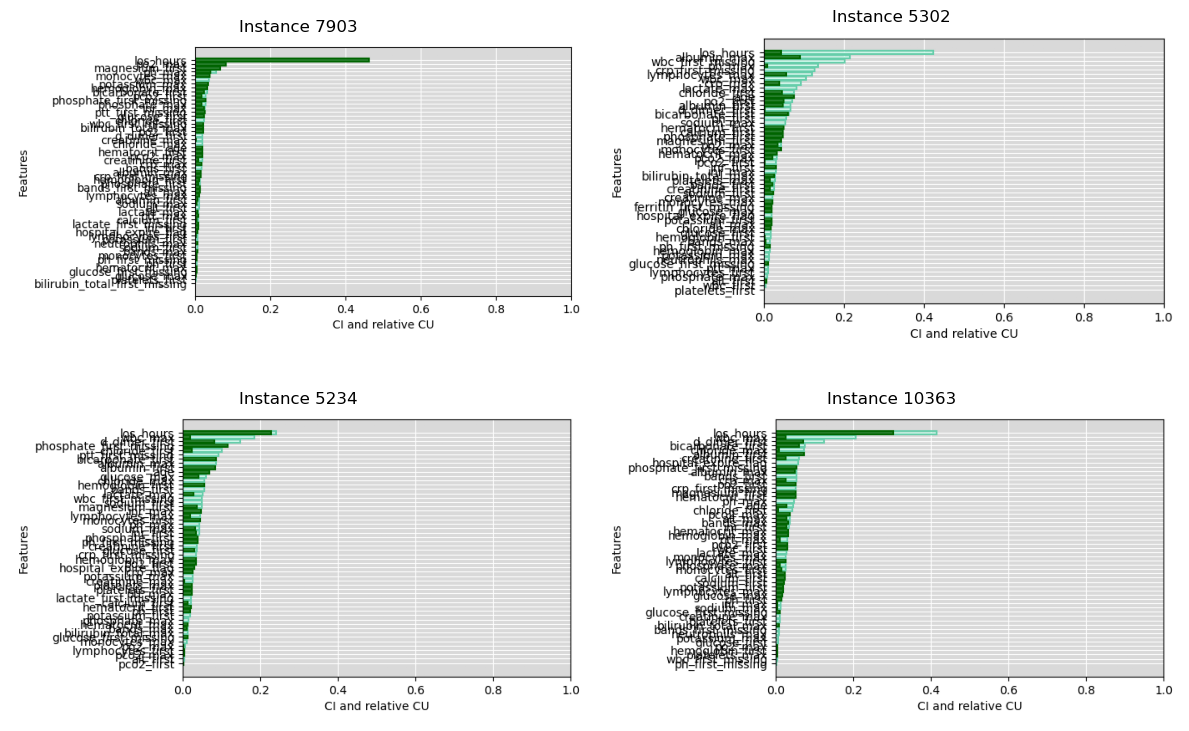

In [33]:
plot_ciu_instances(ciu_results)